#### This practice covers the train test split , feature scaling and column transformations applied using the inbuilt scikit learn framework as well as custom functions using the function transformer

In [1]:
import pandas as pd

df= pd.read_csv("../datasets/employees.csv")
df.head()

,Age,Salary,Department,Education,City,Experience,Promoted
0,23,45000,IT,Bachelors,Nairobi,1,No
1,31,72000,Finance,Masters,Mombasa,5,Yes
2,28,58000,IT,Bachelors,Nairobi,3,No
3,42,95000,HR,PhD,Kisumu,12,Yes
4,35,68000,Marketing,Masters,Nairobi,7,Yes


In [2]:
y=df["Promoted"]
y

0      No
1     Yes
2      No
3     Yes
4     Yes
5      No
6      No
7     Yes
8      No
9     Yes
10     No
11    Yes
12     No
13    Yes
14    Yes
15     No
16    Yes
17    Yes
18     No
19    Yes
20     No
21    Yes
22    Yes
23     No
24    Yes
25     No
26    Yes
27    Yes
28     No
29    Yes
30     No
31    Yes
32    Yes
33     No
34    Yes
35     No
36    Yes
37     No
38    Yes
39    Yes
40     No
41    Yes
42     No
43    Yes
44    Yes
45     No
46    Yes
47     No
48    Yes
49     No
Name: Promoted, dtype: str

In [3]:
x=df.drop(columns="Promoted")
x

,Age,Salary,Department,Education,City,Experience
0,23,45000,IT,Bachelors,Nairobi,1
1,31,72000,Finance,Masters,Mombasa,5
2,28,58000,IT,Bachelors,Nairobi,3
3,42,95000,HR,PhD,Kisumu,12
4,35,68000,Marketing,Masters,Nairobi,7
5,24,42000,Finance,Bachelors,Eldoret,1
6,29,61000,IT,Masters,Nakuru,4
7,38,83000,HR,Bachelors,Mombasa,9
8,26,50000,Marketing,Bachelors,Kisumu,2
9,45,110000,Finance,PhD,Nairobi,18


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X_train,X_test,y_train,y_test=train_test_split(x,y,random_state=20,test_size=0.2)

In [6]:
print(X_test.shape)
print(X_train.shape)
print("==========")
print(y_test.shape)
print(y_train.shape)

(10, 6)
(40, 6)
(10,)
(40,)


In [7]:
X_train.head()

,Age,Salary,Department,Education,City,Experience
40,23,41000,Finance,Bachelors,Nairobi,1
17,39,85000,HR,Bachelors,Nairobi,10
18,28,56000,IT,Bachelors,Mombasa,3
0,23,45000,IT,Bachelors,Nairobi,1
27,35,74000,Finance,Bachelors,Nairobi,8


In [8]:
items = [['Bachelors', 'Masters', 'PhD']]

In [9]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
encoder= OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
    drop='first'
).set_output(transform='pandas')

In [10]:
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
    drop='first'),
    ['Department','City']
                
        ),
        (
            'ordinal',
            OrdinalEncoder(
                categories=items,         
            ),
            ["Education"]
        ),
        (
            'scaler',
            StandardScaler(),
            ['Age','Salary','Experience']
        )


    ],remainder='passthrough'
).set_output(transform="pandas")




In [11]:
X_train_transformed=preprocessor.fit_transform(X_train)
X_train_transformed.head()

,cat__Department_HR,cat__Department_IT,cat__Department_Marketing,cat__City_Kisumu,cat__City_Mombasa,cat__City_Nairobi,cat__City_Nakuru,ordinal__Education,scaler__Age,scaler__Salary,scaler__Experience
40,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.507440,-1.511293,-1.286714
17,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.886510,0.775789,0.603968
18,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.759331,-0.731606,-0.866563
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.507440,-1.303377,-1.286714
27,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.288022,0.204018,0.183816


In [12]:
X_train_transformed.shape

(40, 11)

In [13]:
X_test_transformed=preprocessor.transform(X_test)

In [14]:
X_test_transformed.shape

(10, 11)

In [15]:
y_train

40     No
17    Yes
18     No
0      No
27    Yes
33     No
36    Yes
42     No
10     No
3     Yes
41    Yes
13    Yes
46    Yes
2      No
38    Yes
39    Yes
5      No
43    Yes
37     No
30     No
6      No
29    Yes
16    Yes
19    Yes
49     No
44    Yes
21    Yes
32    Yes
34    Yes
7     Yes
22    Yes
11    Yes
20     No
9     Yes
48    Yes
28     No
31    Yes
15     No
26    Yes
35     No
Name: Promoted, dtype: str

<Axes: >

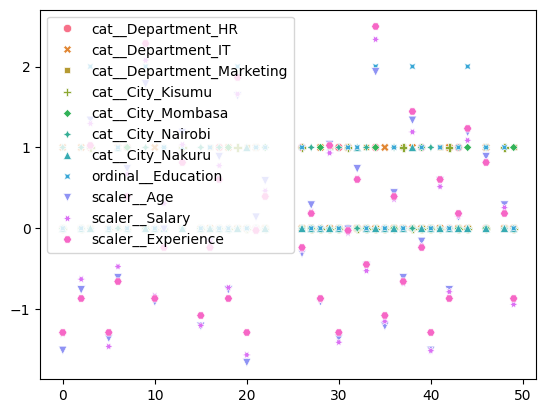

In [16]:
import seaborn as sns
sns.scatterplot(X_train_transformed)

In [17]:
X_train_transformed.head()

,cat__Department_HR,cat__Department_IT,cat__Department_Marketing,cat__City_Kisumu,cat__City_Mombasa,cat__City_Nairobi,cat__City_Nakuru,ordinal__Education,scaler__Age,scaler__Salary,scaler__Experience
40,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.507440,-1.511293,-1.286714
17,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.886510,0.775789,0.603968
18,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.759331,-0.731606,-0.866563
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.507440,-1.303377,-1.286714
27,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.288022,0.204018,0.183816


In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
model = LogisticRegression()

In [20]:
model.fit(X_train_transformed,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred=model.predict(X_test_transformed)

In [22]:
y_pred

array(['No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No'],
      dtype=object)

In [23]:
y_test

12     No
14    Yes
4     Yes
8      No
45     No
1     Yes
25     No
24    Yes
47     No
23     No
Name: Promoted, dtype: str

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy=accuracy_score(y_pred,y_test)

In [26]:
accuracy

1.0

In [27]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_pred,y_test)

In [28]:
cm 

array([[6, 0],
       [0, 4]])